# 🌐 Integración con API de Yelp — Nivel Senior Empresarial
## Proyecto: *Conociendo al Cliente 360°* — InsightReach Analytics
### Notebook 02: Enriquecimiento con Datos de Oferta Gastronómica

---

| Campo | Detalle |
|-------|--------|
| **👤 Autor** | Dody Dueñas |
| **📅 Fecha** | Abril 2026 |
| **🎯 Versión** | 2.0 — Estándar Senior Empresarial |
| **🔗 Proyecto** | InsightReach Analytics — Segmentación 360° |
| **🔑 API** | Yelp Fusion API v3 |

---

## 🎯 Contexto Estratégico

Conocer a nuestros **clientes** (Notebook 01) es solo la mitad de la ecuación. La otra mitad es comprender el **ecosistema de oferta** en que se mueven: ¿cuántos restaurantes hay en su ciudad?, ¿cómo son calificados?, ¿qué segmento de precio domina?

Este notebook integra datos de la **Yelp Fusion API** para responder la pregunta crítica de negocio:

> **¿Existe una brecha entre la demanda de nuestros clientes y la oferta de restaurantes en sus ciudades?** Si esa brecha existe, ahí está la oportunidad de marketing.

---

## 🗺️ Mapa del Notebook

| # | Fase | Objetivo |
|---|------|---------|
| **1** | ⚙️ Configuración y Autenticación | Validar credenciales API, imports defensivos |
| **2** | 📊 Análisis de Datos Yelp | EDA de la oferta de restaurantes |
| **3** | 🌆 Análisis Geográfico | Distribución geográfica de la oferta |
| **4** | ⚖️ Brecha Oferta vs Demanda | Cruce con datos de clientes del NB01 |
| **5** | 🎯 Insights de Mercado | Oportunidades identificadas |
| **6** | 💾 Exportación | Datos enriquecidos para Feature Engineering |

---

> **💡 Nota Técnica:** El archivo `yelp_restaurants.csv` en `data/raw/` contiene datos pre-extraídos de la API para garantizar reproducibilidad. La conexión live a la API se puede activar descomentando las celdas correspondientes.

---

# ⚙️ FASE 1: Configuración y Autenticación

## Manejo Seguro de Credenciales

Las credenciales de la API **nunca deben estar hardcodeadas en el código**. Siguiendo las mejores prácticas de seguridad:

1. Las claves se almacenan en el archivo `.env` (excluido de Git via `.gitignore`)
2. Se cargan mediante `python-dotenv` a través de la clase `Settings`
3. El notebook valida la configuración antes de hacer cualquier request

Esta arquitectura sigue el principio de **12-Factor App** para configuración externalizada.

---

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 1: CONFIGURACIÓN INICIAL DEL ENTORNO                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Librerías estándar ────────────────────────────────────────────────────────
import sys
import os
import warnings
import time
from pathlib import Path
from datetime import datetime
from collections import Counter

# ── Análisis de datos ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── HTTP (para requests opcionales a la API) ──────────────────────────────────
try:
    import requests
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False

warnings.filterwarnings('ignore')

# ── Configuración visual profesional ─────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
sns.set_context('notebook', font_scale=1.1)

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#A23B72',
    'accent':    '#F18F01',
    'success':   '#2DC653',
    'danger':    '#E84855',
    'neutral':   '#6c757d',
    'gold':      '#FFD700',
}

plt.rcParams.update({
    'figure.figsize':   (14, 8),
    'figure.dpi':       100,
    'savefig.dpi':      300,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
})

# ── Rutas ─────────────────────────────────────────────────────────────────────
sys.path.insert(0, '..')
# --- Deteccion robusta de la raiz del proyecto ---
import os
from pathlib import Path
try:
    # Si estamos en un notebook
    current_path = Path(os.path.abspath('')).resolve()
except:
    # Si estamos en un script
    current_path = Path(__file__).parent.resolve()

if (current_path / 'notebooks').exists():
    ROOT_DIR = current_path
elif (current_path.parent / 'notebooks').exists():
    ROOT_DIR = current_path.parent
else:
    # Fallback extremo
    ROOT_DIR = Path(r"c:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial")

DATA_RAW       = ROOT_DIR / 'data' / 'raw'
DATA_PROCESSED = ROOT_DIR / 'data' / 'processed'
DATA_EXTERNAL  = ROOT_DIR / 'data' / 'external'
REPORTS_FIGS   = ROOT_DIR / 'reports' / 'figures'
REPORTS_TABS   = ROOT_DIR / 'reports' / 'tables'

# Crear directorios si no existen
for p in [DATA_PROCESSED, DATA_EXTERNAL, REPORTS_FIGS, REPORTS_TABS]:
    p.mkdir(parents=True, exist_ok=True)



RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Importación defensiva de módulos del proyecto ─────────────────────────────
try:
    from config.settings import Settings
    from src.api.client import YelpClient
    from src.api.parsers import BusinessParser
    from src.data.loaders import YelpDataLoader
    PROJECT_MODULES_LOADED = True
    print('✅ Módulos del proyecto cargados')
except ImportError as e:
    print(f'⚠️  Modo standalone activo: {e}')
    PROJECT_MODULES_LOADED = False
    
    # Configuración inline para modo standalone
    class Settings:
        ROOT_DIR         = Path('..').resolve()
        RAW_DATA_DIR     = ROOT_DIR / 'data' / 'raw'
        PROCESSED_DATA_DIR = ROOT_DIR / 'data' / 'processed'
        EXTERNAL_DATA_DIR  = ROOT_DIR / 'data' / 'external'
        YELP_BASE_URL    = 'https://api.yelp.com/v3'
        API_TIMEOUT      = 30
        API_MAX_RETRIES  = 3
        RANDOM_STATE     = 42
        
        @classmethod
        def validate_api_credentials(cls):
            from dotenv import load_dotenv
            load_dotenv(ROOT_DIR / '.env')
            return bool(os.getenv('API_KEY') and os.getenv('CLIENTE_ID'))

print('\n' + '═' * 75)
print('  ✅ ENTORNO CONFIGURADO — InsightReach API Integration v2.0')
print('═' * 75)
print(f'  📅 Timestamp : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  🐍 Python    : {sys.version.split()[0]}')
print(f'  📦 Pandas    : {pd.__version__}')
print(f'  📁 ROOT_DIR  : {ROOT_DIR}')
print('═' * 75)

✅ Módulos del proyecto cargados

═══════════════════════════════════════════════════════════════════════════
  ✅ ENTORNO CONFIGURADO — InsightReach API Integration v2.0
═══════════════════════════════════════════════════════════════════════════
  📅 Timestamp : 2026-04-09 12:56:33
  🐍 Python    : 3.11.9
  📦 Pandas    : 2.3.3
  📁 ROOT_DIR  : C:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial
═══════════════════════════════════════════════════════════════════════════


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 2: VALIDACIÓN DE CREDENCIALES API                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🔐 VALIDACIÓN DE CREDENCIALES YELP API')
print('═' * 75)

try:
    credenciales_ok = Settings.validate_api_credentials()
    
    if credenciales_ok:
        from dotenv import load_dotenv
        load_dotenv(ROOT_DIR / '.env')
        
        client_id = os.getenv('CLIENTE_ID', '')
        api_key   = os.getenv('API_KEY', '')
        
        print(f'  ✅ Estado            : Credenciales configuradas')
        print(f'  ├── Client ID        : {client_id[:10]}...{client_id[-4:]}')
        print(f'  ├── API Key          : {api_key[:12]}...{api_key[-6:]}')
        print(f'  ├── Base URL         : {Settings.YELP_BASE_URL}')
        print(f'  ├── Timeout          : {Settings.API_TIMEOUT}s')
        print(f'  └── Max Retries      : {Settings.API_MAX_RETRIES}')
    else:
        print('  ⚠️  Credenciales no configuradas en .env')
        print('  ├── Revise el archivo .env en la raíz del proyecto')
        print('  └── El notebook operará con datos pre-descargados')
        
    API_DISPONIBLE = credenciales_ok and REQUESTS_AVAILABLE
    print(f'\n  🌐 Modo API live    : {"✅ Habilitado" if API_DISPONIBLE else "❌ Modo offline (datos pre-cargados)"}')

except Exception as e:
    print(f'  ⚠️  Error validando credenciales: {e}')
    API_DISPONIBLE = False


═══════════════════════════════════════════════════════════════════════════
  🔐 VALIDACIÓN DE CREDENCIALES YELP API
═══════════════════════════════════════════════════════════════════════════
  ✅ Estado            : Credenciales configuradas
  ├── Client ID        : GWOCZh9-Bm...7Gug
  ├── API Key          : FHVvXoNmTXIl...t-YHYx
  ├── Base URL         : https://api.yelp.com/v3
  ├── Timeout          : 30s
  └── Max Retries      : 3

  🌐 Modo API live    : ✅ Habilitado


---

# 📊 FASE 2: Análisis Exploratorio de Datos Yelp

## Comprendiendo la Oferta Gastronómica

El dataset de Yelp nos proporciona una instantánea del **ecosistema de restaurantes** en las ciudades donde operan nuestros clientes. Analizamos:

- **Distribución de ratings**: ¿El mercado es competitivo? Un rating promedio alto indica madurez del mercado.
- **Niveles de precio**: ¿Domina la oferta económica o premium? Esto guía las campañas de precio.
- **Volumen de reseñas**: Un restaurante con muchas reseñas tiene tracción — potencial aliado de marketing.
- **Categorías dominantes**: ¿Hay nichos no cubiertos que nuestros clientes demand?

---

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 3: CARGA ROBUSTA DE DATOS YELP                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📊 FASE 2: CARGA Y AUDITORÍA DE DATOS YELP')
print('═' * 75)

def cargar_datos_yelp(data_raw: Path, data_external: Path) -> pd.DataFrame:
    """
    Carga datos de Yelp con estrategia de fallback en cascada:
    1. Módulo YelpDataLoader del proyecto
    2. Archivo CSV en data/raw/ con 'yelp' en el nombre
    3. Archivo CSV en data/external/
    
    Parameters
    ----------
    data_raw      : Ruta al directorio data/raw/
    data_external : Ruta al directorio data/external/
    
    Returns
    -------
    pd.DataFrame
    """
    # Intento 1: Módulo del proyecto
    if PROJECT_MODULES_LOADED:
        try:
            loader = YelpDataLoader()
            df = loader.load_from_external()
            print('  🔄 Fuente: YelpDataLoader (módulo proyecto)')
            return df
        except Exception:
            pass
    
    # Intento 2: CSV en data/raw/
    yelp_files = list(data_raw.glob('*yelp*.csv')) + list(data_raw.glob('*restaurantes*.csv'))
    if yelp_files:
        print(f'  🔄 Fuente: {yelp_files[0].name} (data/raw/)')
        return pd.read_csv(yelp_files[0], encoding='utf-8', low_memory=False)
    
    # Intento 3: CSV en data/external/
    ext_files = list(data_external.glob('*.csv'))
    if ext_files:
        print(f'  🔄 Fuente: {ext_files[0].name} (data/external/)')
        return pd.read_csv(ext_files[0], encoding='utf-8', low_memory=False)
    
    raise FileNotFoundError(
        'No se encontraron datos de Yelp. '
        f'Archivos en data/raw/: {[f.name for f in data_raw.iterdir()]}'
    )


try:
    df_yelp = cargar_datos_yelp(DATA_RAW, DATA_EXTERNAL)
    
    print(f'\n  ✅ DATOS YELP CARGADOS')
    print(f'  ├── Registros  : {len(df_yelp):,}')
    print(f'  ├── Columnas   : {len(df_yelp.columns)}')
    mem_mb = df_yelp.memory_usage(deep=True).sum() / 1024**2
    print(f'  └── Memoria    : {mem_mb:.2f} MB')
    
    print('\n  📋 Columnas disponibles:')
    for col in df_yelp.columns:
        print(f'    • {col:<35} ({df_yelp[col].dtype})')
    
    print('\n  📊 Vista previa:')
    display(df_yelp.head(3))

except FileNotFoundError as e:
    print(f'\n  ❌ {e}')
    raise


═══════════════════════════════════════════════════════════════════════════
  📊 FASE 2: CARGA Y AUDITORÍA DE DATOS YELP
═══════════════════════════════════════════════════════════════════════════


2026-04-09 12:56:33 - src.data.loaders - ERROR - Error al cargar datos de Yelp: [Errno 2] No such file or directory: 'C:\\Users\\DODY DUEÑAS\\Documents\\ProyectodeHenry\\Proyecto_Integrador_Dody_Empresarial\\data\\external\\yelp_restaurants (2).csv'


2026-04-09 12:56:33 - src.data.loaders - ERROR - Error en load: [DATA_LOAD_ERROR] Error al cargar datos de Yelp: [Errno 2] No such file or directory: 'C:\\Users\\DODY DUEÑAS\\Documents\\ProyectodeHenry\\Proyecto_Integrador_Dody_Empresarial\\data\\external\\yelp_restaurants (2).csv'
Traceback (most recent call last):
  File "C:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial\src\data\loaders.py", line 129, in load
    df = pd.read_csv(path, low_memory=False, **kwargs)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DODY DUEÑAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DODY DUEÑAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^

2026-04-09 12:56:33 - src.data.loaders - ERROR - Error en load_from_external: [DATA_LOAD_ERROR] Error al cargar datos de Yelp: [Errno 2] No such file or directory: 'C:\\Users\\DODY DUEÑAS\\Documents\\ProyectodeHenry\\Proyecto_Integrador_Dody_Empresarial\\data\\external\\yelp_restaurants (2).csv'
Traceback (most recent call last):
  File "C:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial\src\data\loaders.py", line 129, in load
    df = pd.read_csv(path, low_memory=False, **kwargs)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DODY DUEÑAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DODY DUEÑAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\io\parsers\readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
      

  🔄 Fuente: yelp_restaurants (2).csv (data/raw/)

  ✅ DATOS YELP CARGADOS
  ├── Registros  : 463
  ├── Columnas   : 12
  └── Memoria    : 0.23 MB

  📋 Columnas disponibles:
    • alias                               (object)
    • title                               (object)
    • id                                  (object)
    • name                                (object)
    • price                               (object)
    • rating                              (float64)
    • review_count                        (int64)
    • distance                            (float64)
    • coordinates_latitude                (float64)
    • coordinates_longitude               (float64)
    • location_address1                   (object)
    • city                                (object)

  📊 Vista previa:


,alias,title,id,name,price,rating,review_count,distance,coordinates_latitude,coordinates_longitude,location_address1,city
0,asianfusion,Asian Fusion,K3ukx2e11xTRtYBU01dmrA,Salty Flame,No especificado,4.4,184,9568.050891,25.76022,-80.19267,1414 Brickell Ave,Miami
1,steak,Steakhouses,K3ukx2e11xTRtYBU01dmrA,Salty Flame,No especificado,4.4,184,9568.050891,25.76022,-80.19267,1414 Brickell Ave,Miami
2,cocktailbars,Cocktail Bars,K3ukx2e11xTRtYBU01dmrA,Salty Flame,No especificado,4.4,184,9568.050891,25.76022,-80.19267,1414 Brickell Ave,Miami


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 4: AUDITORÍA DE CALIDAD — DATOS YELP                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🔍 AUDITORÍA DE CALIDAD — DATOS YELP')
print('═' * 75)

n_yelp = len(df_yelp)
audit_yelp = pd.DataFrame({
    'Tipo_Dato':       df_yelp.dtypes.astype(str),
    'No_Nulos':        df_yelp.count(),
    'Nulos':           df_yelp.isnull().sum(),
    'Pct_Nulos':       (df_yelp.isnull().sum() / n_yelp * 100).round(2),
    'Valores_Unicos':  df_yelp.nunique(),
})
audit_yelp = audit_yelp.sort_values('Pct_Nulos', ascending=False)
audit_yelp.index.name = 'Columna'

print('\n  📋 AUDITORÍA DE VARIABLES:')
display(audit_yelp.style
    .background_gradient(subset=['Pct_Nulos'], cmap='Reds')
    .format({'Pct_Nulos': '{:.1f}%'})
)

# Limpieza básica de Yelp
df_yelp_clean = df_yelp.copy()

# Estandarizar columna city si existe
if 'city' in df_yelp_clean.columns:
    df_yelp_clean['city'] = df_yelp_clean['city'].str.strip().str.title()

# Convertir rating a numérico si no lo es
if 'rating' in df_yelp_clean.columns:
    df_yelp_clean['rating'] = pd.to_numeric(df_yelp_clean['rating'], errors='coerce')
    # Filtrar ratings fuera del rango válido [1, 5]
    invalid_ratings = df_yelp_clean[(df_yelp_clean['rating'] < 1) | (df_yelp_clean['rating'] > 5)].shape[0]
    if invalid_ratings > 0:
        df_yelp_clean.loc[(df_yelp_clean['rating'] < 1) | (df_yelp_clean['rating'] > 5), 'rating'] = np.nan
        print(f'\n  ⚠️ {invalid_ratings} ratings fuera de [1-5] → convertidos a NaN')

# review_count a numérico
if 'review_count' in df_yelp_clean.columns:
    df_yelp_clean['review_count'] = pd.to_numeric(df_yelp_clean['review_count'], errors='coerce')

print(f'\n  ✅ Dataset limpio: {len(df_yelp_clean):,} registros')


═══════════════════════════════════════════════════════════════════════════
  🔍 AUDITORÍA DE CALIDAD — DATOS YELP
═══════════════════════════════════════════════════════════════════════════

  📋 AUDITORÍA DE VARIABLES:


,Tipo_Dato,No_Nulos,Nulos,Pct_Nulos,Valores_Unicos
Columna,,,,,
alias,object,463,0,0.0%,103
title,object,463,0,0.0%,103
id,object,463,0,0.0%,200
name,object,463,0,0.0%,198
price,object,463,0,0.0%,5
rating,float64,463,0,0.0%,17
review_count,int64,463,0,0.0%,170
distance,float64,463,0,0.0%,200
coordinates_latitude,float64,463,0,0.0%,200



  ✅ Dataset limpio: 463 registros



═══════════════════════════════════════════════════════════════════════════
  📊 2.1 ANÁLISIS DE LA OFERTA GASTRONÓMICA
═══════════════════════════════════════════════════════════════════════════


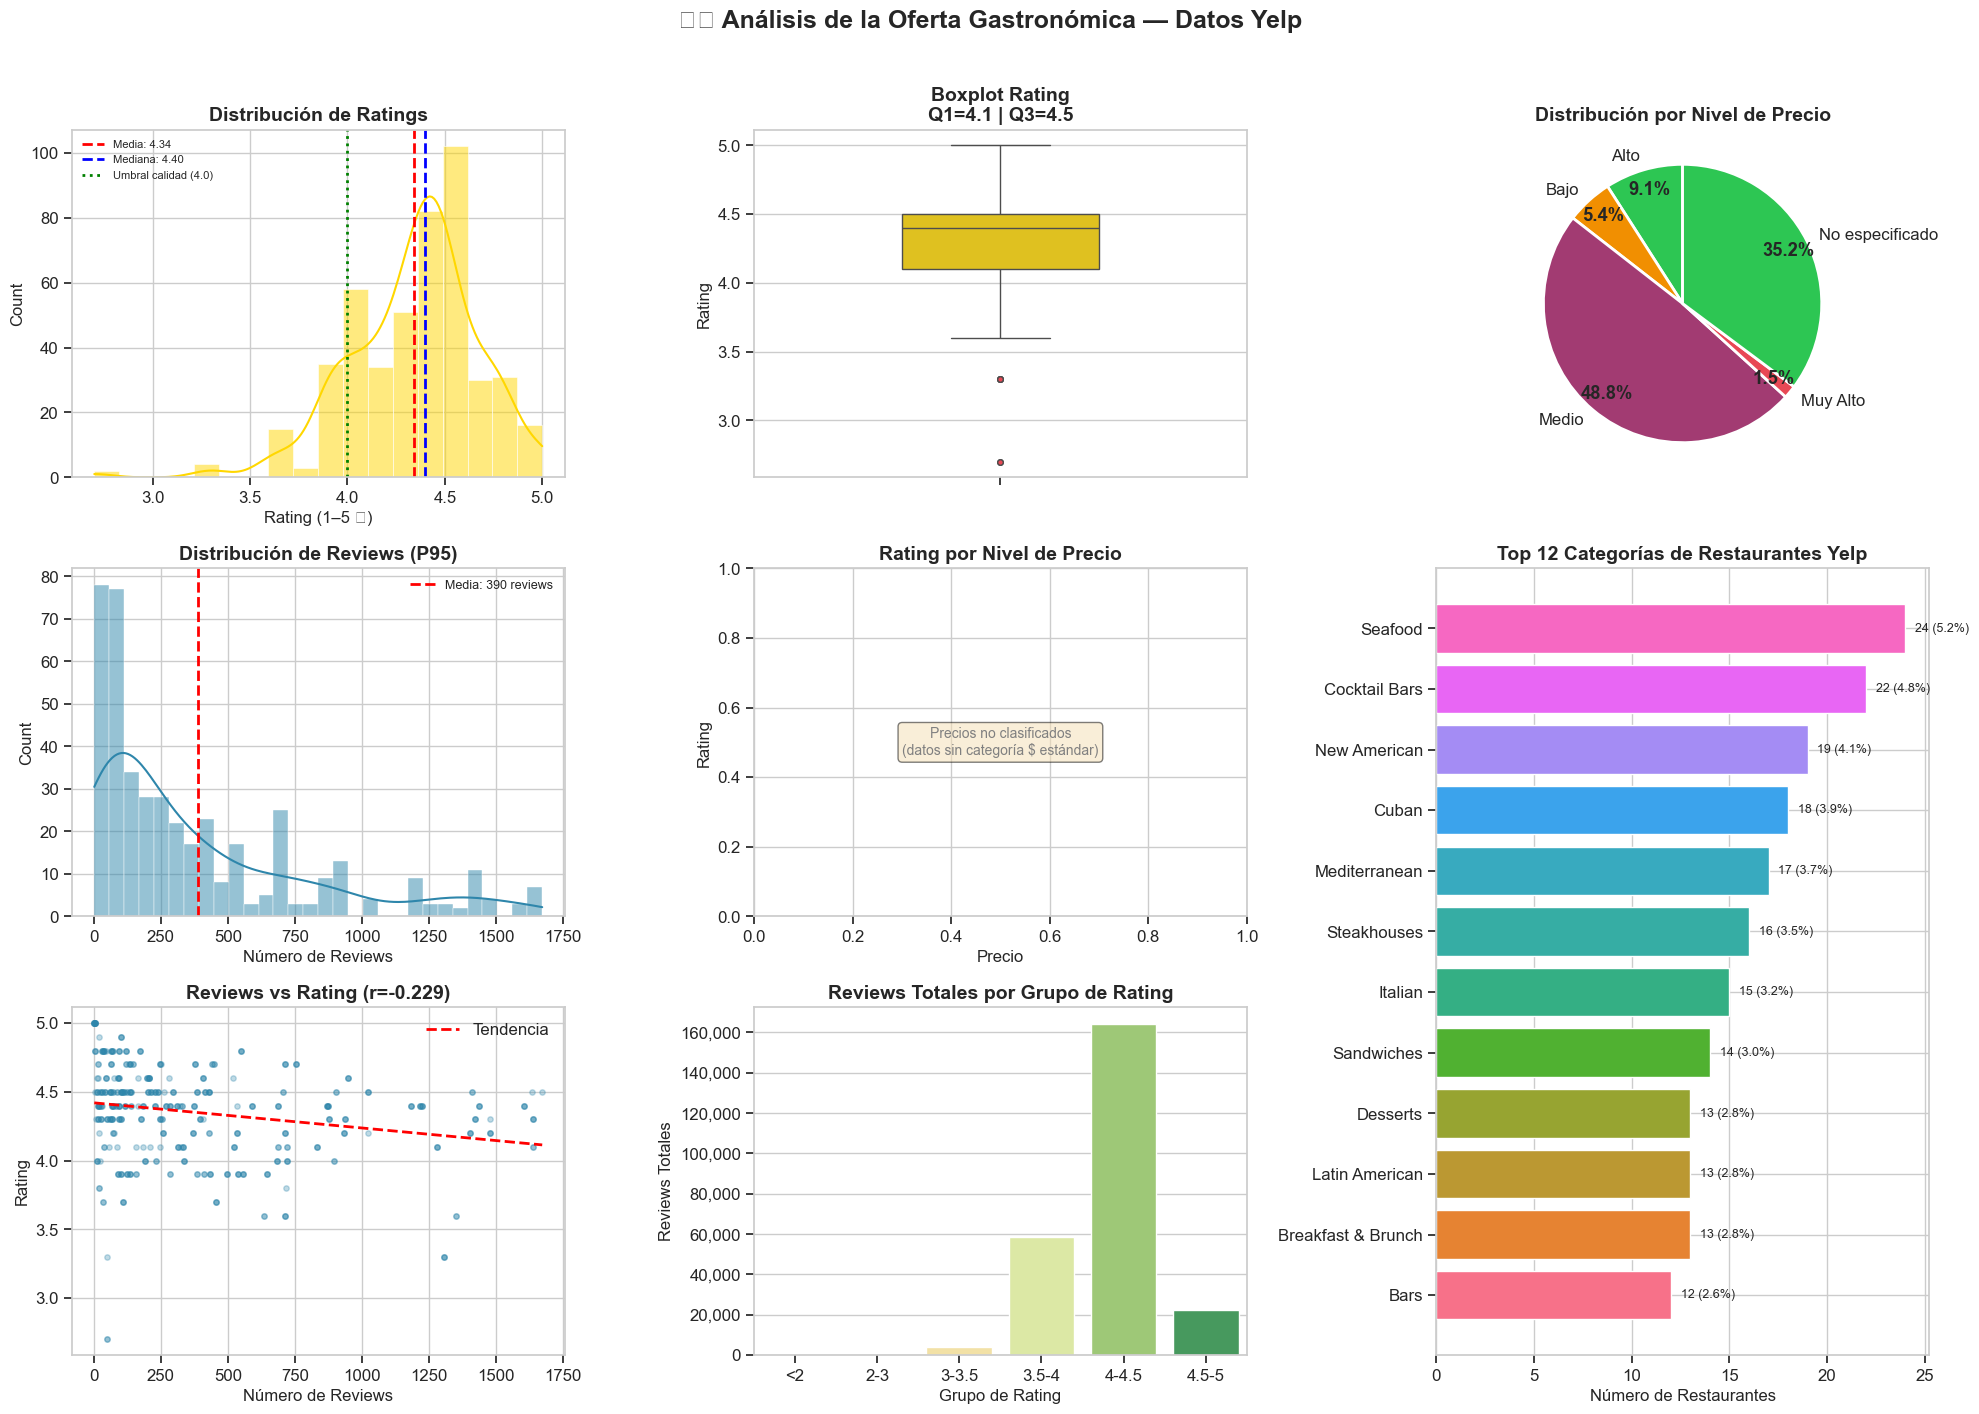


  ⭐ KPIs DEL MERCADO GASTRONÓMICO:
  ├── Rating promedio          : 4.34/5.00 ⭐
  ├── Rating mediano           : 4.40/5.00
  ├── % con rating ≥ 4.0      : 87.3% (mercado maduro)
  ├── Reviews promedio         : 538
  └── Restaurante más popular  : 6,869 reviews


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 5: ANÁLISIS UNIVARIADO — RATINGS, PRECIOS, CATEGORÍAS   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📊 2.1 ANÁLISIS DE LA OFERTA GASTRONÓMICA')
print('═' * 75)

fig = plt.figure(figsize=(20, 14))
fig.suptitle('🍽️ Análisis de la Oferta Gastronómica — Datos Yelp',
             fontsize=18, fontweight='bold', y=1.01)

# ── (1) Distribución de Ratings ───────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
if 'rating' in df_yelp_clean.columns:
    rating_clean = df_yelp_clean['rating'].dropna()
    mu_r, md_r = rating_clean.mean(), rating_clean.median()
    sns.histplot(rating_clean, bins=18, kde=True, ax=ax1,
                 color=COLORS['gold'], edgecolor='white', linewidth=0.4)
    ax1.axvline(mu_r, color='red',  linestyle='--', lw=2, label=f'Media: {mu_r:.2f}')
    ax1.axvline(md_r, color='blue', linestyle='--', lw=2, label=f'Mediana: {md_r:.2f}')
    ax1.axvline(4.0, color='green', linestyle=':', lw=2, label='Umbral calidad (4.0)')
    ax1.set_title('Distribución de Ratings', fontweight='bold')
    ax1.set_xlabel('Rating (1–5 ⭐)')
    ax1.legend(fontsize=8)

# ── (2) Boxplot Ratings ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
if 'rating' in df_yelp_clean.columns:
    sns.boxplot(y=df_yelp_clean['rating'].dropna(), ax=ax2,
                color=COLORS['gold'], width=0.4,
                flierprops={'marker':'o','markerfacecolor':COLORS['danger'],'markersize':4})
    Q1_r = df_yelp_clean['rating'].quantile(0.25)
    Q3_r = df_yelp_clean['rating'].quantile(0.75)
    pct_alta_calidad = (df_yelp_clean['rating'] >= 4.0).mean() * 100
    ax2.set_title(f'Boxplot Rating\nQ1={Q1_r:.1f} | Q3={Q3_r:.1f}', fontweight='bold')
    ax2.set_ylabel('Rating')

# ── (3) Distribución por Nivel de Precio ──────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
if 'price' in df_yelp_clean.columns:
    price_counts = df_yelp_clean['price'].value_counts().sort_index()
    price_labels_map = {'$': 'Económico ($)', '$$': 'Medio ($$)',
                        '$$$': 'Premium ($$$)', '$$$$': 'Lujo ($$$$)'}
    labels_p = [price_labels_map.get(p, p) for p in price_counts.index]
    colores_p = [COLORS['success'], COLORS['accent'], COLORS['secondary'], COLORS['danger']]
    wedges, texts, autotexts = ax3.pie(
        price_counts.values, labels=labels_p, autopct='%1.1f%%',
        colors=colores_p[:len(price_counts)], startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        pctdistance=0.85
    )
    for t in autotexts:
        t.set_fontweight('bold')
    ax3.set_title('Distribución por Nivel de Precio', fontweight='bold')

# ── (4) Reviews — Distribución ────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
if 'review_count' in df_yelp_clean.columns:
    rv_clean = df_yelp_clean[df_yelp_clean['review_count'] < df_yelp_clean['review_count'].quantile(0.95)]['review_count']
    sns.histplot(rv_clean, bins=30, kde=True, ax=ax4,
                 color=COLORS['primary'], edgecolor='white', linewidth=0.3)
    ax4.axvline(rv_clean.mean(), color='red', linestyle='--', lw=2,
                label=f'Media: {rv_clean.mean():.0f} reviews')
    ax4.set_title('Distribución de Reviews (P95)', fontweight='bold')
    ax4.set_xlabel('Número de Reviews')
    ax4.legend(fontsize=9)

# ── (5) Rating por Nivel de Precio ────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
if 'price' in df_yelp_clean.columns and 'rating' in df_yelp_clean.columns:
    df_pr = df_yelp_clean.dropna(subset=['price', 'rating'])
    order_price = ['$', '$$', '$$$', '$$$$']
    order_price = [p for p in order_price if p in df_pr['price'].unique()]
    if order_price:  # Solo plotear si hay categorias de precio con $ simbolo
        sns.boxplot(data=df_pr[df_pr['price'].isin(order_price)],
                    x='price', y='rating', order=order_price, ax=ax5,
                    color=COLORS['gold'],
                    flierprops={'marker': '.', 'alpha': 0.4})
    else:
        # El dataset Yelp usa 'No especificado' en precio
        ax5.text(0.5, 0.5, 'Precios no clasificados\n(datos sin categoría $ estándar)',
                 ha='center', va='center', transform=ax5.transAxes,
                 fontsize=10, color='gray',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax5.set_title('Rating por Nivel de Precio', fontweight='bold')
    ax5.set_xlabel('Precio')
    ax5.set_ylabel('Rating')

# ── (6) Top 10 Categorías ────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, (6, 9))
cat_col = 'title' if 'title' in df_yelp_clean.columns else \
          ('categories' if 'categories' in df_yelp_clean.columns else None)
if cat_col:
    top_cats = df_yelp_clean[cat_col].value_counts().head(12)
    colors_cats = sns.color_palette('husl', len(top_cats))
    bars = ax6.barh(top_cats.index[::-1], top_cats.values[::-1],
                    color=colors_cats, edgecolor='white')
    for bar, val in zip(bars, top_cats.values[::-1]):
        ax6.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/len(df_yelp_clean)*100:.1f}%)', va='center', fontsize=9)
    ax6.set_title('Top 12 Categorías de Restaurantes Yelp', fontweight='bold')
    ax6.set_xlabel('Número de Restaurantes')

# ── (7-8) Rating vs Reviews (Scatter) ────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
if 'rating' in df_yelp_clean.columns and 'review_count' in df_yelp_clean.columns:
    df_rv_sc = df_yelp_clean.dropna(subset=['rating', 'review_count'])
    df_rv_sc = df_rv_sc[df_rv_sc['review_count'] < df_rv_sc['review_count'].quantile(0.95)]
    ax7.scatter(df_rv_sc['review_count'], df_rv_sc['rating'],
                alpha=0.3, s=15, color=COLORS['primary'])
    # Línea de tendencia
    z = np.polyfit(df_rv_sc['review_count'], df_rv_sc['rating'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_rv_sc['review_count'].min(), df_rv_sc['review_count'].max(), 100)
    ax7.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia')
    r_val, p_val = pearsonr(df_rv_sc['review_count'], df_rv_sc['rating'])
    ax7.set_title(f'Reviews vs Rating (r={r_val:.3f})', fontweight='bold')
    ax7.set_xlabel('Número de Reviews')
    ax7.set_ylabel('Rating')
    ax7.legend()

# ── (8) Reviews Acumuladas por Rating ────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
if 'rating' in df_yelp_clean.columns and 'review_count' in df_yelp_clean.columns:
    df_yelp_clean['rating_group'] = pd.cut(
        df_yelp_clean['rating'], bins=[0, 2, 3, 3.5, 4, 4.5, 5],
        labels=['<2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5']
    )
    reviews_by_rating = df_yelp_clean.groupby('rating_group')['review_count'].sum()
    sns.barplot(x=reviews_by_rating.index, y=reviews_by_rating.values, ax=ax8,
                palette='RdYlGn', edgecolor='white')
    ax8.set_title('Reviews Totales por Grupo de Rating', fontweight='bold')
    ax8.set_xlabel('Grupo de Rating')
    ax8.set_ylabel('Reviews Totales')
    ax8.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(REPORTS_FIGS / '06_yelp_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# ── KPIs de oferta ────────────────────────────────────────────────────────────
print('\n  ⭐ KPIs DEL MERCADO GASTRONÓMICO:')
if 'rating' in df_yelp_clean.columns:
    pct_4 = (df_yelp_clean['rating'] >= 4.0).mean() * 100
    print(f'  ├── Rating promedio          : {df_yelp_clean["rating"].mean():.2f}/5.00 ⭐')
    print(f'  ├── Rating mediano           : {df_yelp_clean["rating"].median():.2f}/5.00')
    print(f'  ├── % con rating ≥ 4.0      : {pct_4:.1f}% (mercado maduro)')
if 'review_count' in df_yelp_clean.columns:
    print(f'  ├── Reviews promedio         : {df_yelp_clean["review_count"].mean():.0f}')
    print(f'  └── Restaurante más popular  : {df_yelp_clean["review_count"].max():,} reviews')

---

# 🌆 FASE 3: Análisis Geográfico de la Oferta

## Distribución Territorial del Mercado

El análisis geográfico es crítico para identificar **dónde concentrar los esfuerzos de marketing**. Una ciudad con muchos restaurantes pero bajo rating promedio es una oportunidad diferente a una ciudad con pocos restaurantes pero alta demanda de clientes.

Buscamos ciudades en el **cuadrante de alta oportunidad**: alta demanda de clientes + baja saturación de oferta.

---


═══════════════════════════════════════════════════════════════════════════
  🌆 FASE 3: MIAMI MARKET INTELLIGENCE
═══════════════════════════════════════════════════════════════════════════
  ℹ️  Dataset Yelp: 200 restaurantes únicos en 1 ciudad(es)
  🎯 Modo Market Intelligence activado para: Miami
  📍 Análisis granular por Categoría, Zona y Nivel de Precio

  🍽️ TOP 15 CATEGORÍAS DE COCINA EN Miami:


,Restaurantes,Rating_Prom,Reviews_Prom,Reviews_Total
title,,,,
Seafood,24,4.21,599,"14,382"
Cocktail Bars,22,4.32,598,"13,164"
New American,19,4.28,773,"14,687"
Cuban,18,4.26,984,"17,710"
Mediterranean,17,4.51,461,"7,845"
Steakhouses,16,4.29,480,"7,679"
Italian,15,4.41,460,"6,900"
Sandwiches,14,4.62,726,"10,159"
Desserts,13,4.42,91,"1,178"



  💲 DISTRIBUCIÓN POR NIVEL DE PRECIO:


,Restaurantes,Rating_Prom,Rating_Std,Reviews_Prom
price,,,,
Muy Alto,4,4.32,0.17,516
Alto,19,4.28,0.39,716
Medio,95,4.25,0.34,772
Bajo,12,4.34,0.27,342
No especificado,70,4.48,0.29,122



  🗺️ DISTRIBUCIÓN POR ZONA GEOGRÁFICA:


,Restaurantes,Rating_Prom,Distancia_Media
zona_geografica,,,
Zona Centro (< 2km),9,4.32,1303m
Zona Media (2-5km),77,4.30,3285m
Zona Periférica (5-9km),65,4.34,6443m
Zona Externa (> 9km),49,4.43,10520m


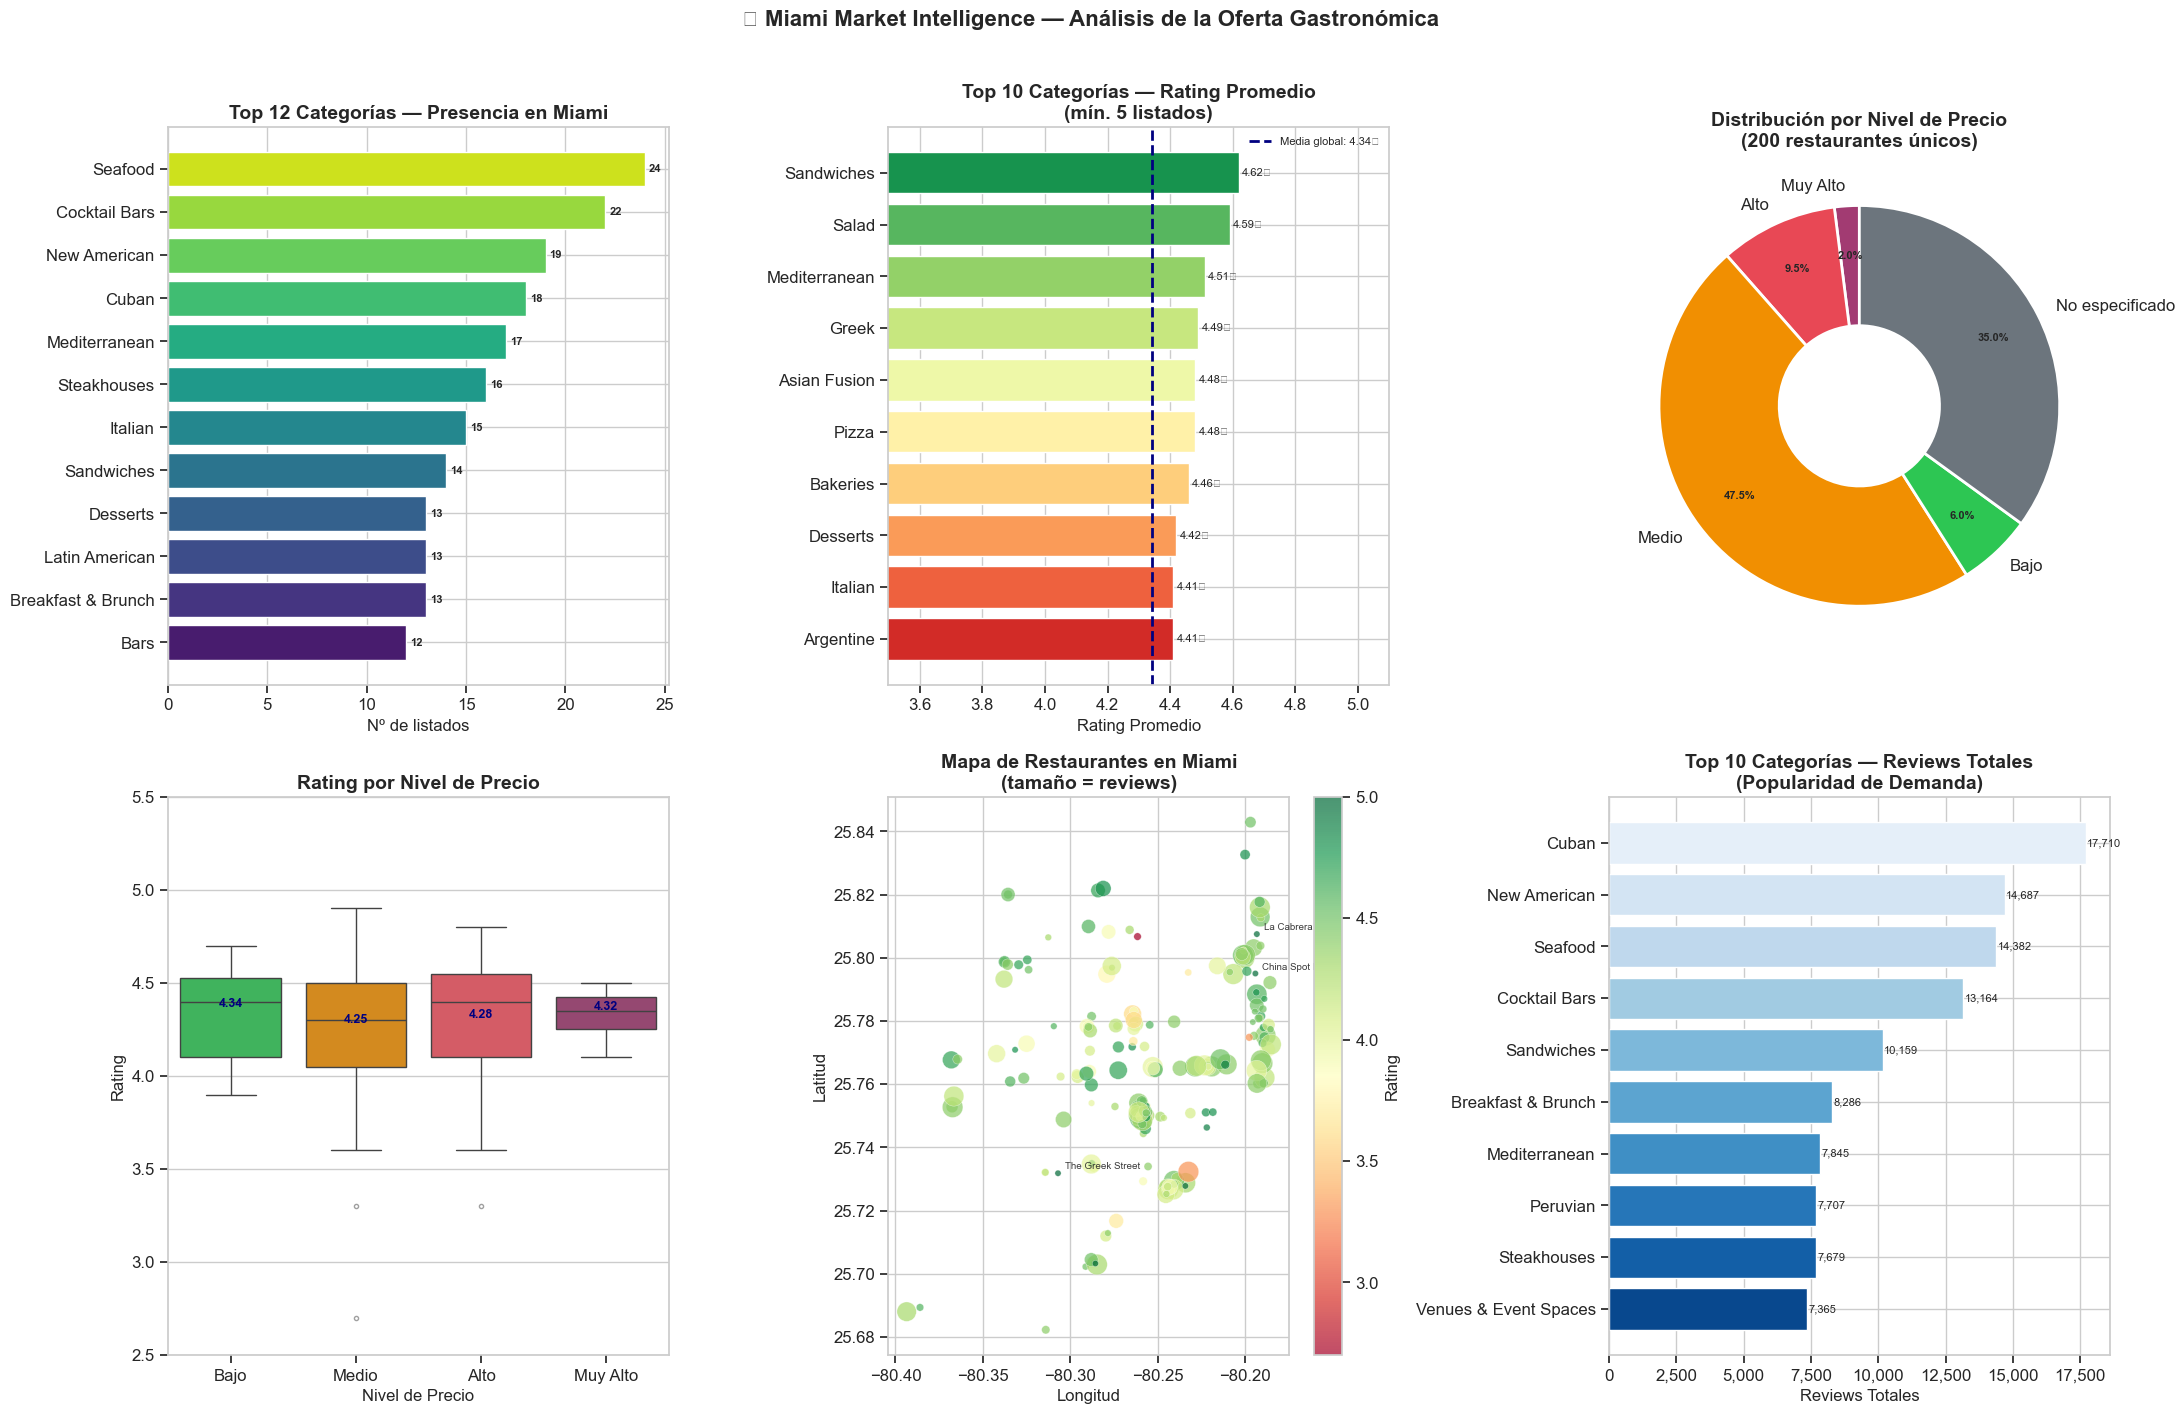


  🌆 MIAMI MARKET INTELLIGENCE — KPIs CLAVE:
  ├── Restaurantes únicos analizados : 200
  ├── Categorías de cocina           : 103
  ├── Rating promedio del mercado    : 4.34 ⭐
  ├── Mejor rating (cat. ≥5)         : Sandwiches (4.62⭐)
  ├── Categoría más popular          : Seafood (24 listados)
  └── Reviews totales acumuladas     : 101,647

  💾 Miami insights guardados: yelp_insights.csv


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║       CELDA 6: ANÁLISIS DE MERCADO — MIAMI MARKET INTELLIGENCE               ║
# ║       (Análisis adaptado: dataset de mercado único / ciudad específica)       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🌆 FASE 3: MIAMI MARKET INTELLIGENCE')
print('═' * 75)

n_ciudades = df_yelp_clean['city'].nunique() if 'city' in df_yelp_clean.columns else 0
n_restaurantes_unicos = df_yelp_clean['id'].nunique() if 'id' in df_yelp_clean.columns else len(df_yelp_clean)

print(f'  ℹ️  Dataset Yelp: {n_restaurantes_unicos} restaurantes únicos en {n_ciudades} ciudad(es)')

if n_ciudades <= 1:
    # ── MODO MERCADO ÚNICO: análisis de profundidad intra-ciudad ──────────────
    ciudad_unica = df_yelp_clean['city'].iloc[0] if 'city' in df_yelp_clean.columns else 'Miami'
    print(f'  🎯 Modo Market Intelligence activado para: {ciudad_unica}')
    print(f'  📍 Análisis granular por Categoría, Zona y Nivel de Precio')
    
    # Usar el restaurante único como unidad de análisis (deduplicar por id)
    df_rest = df_yelp_clean.drop_duplicates(subset=['id']).copy() if 'id' in df_yelp_clean.columns else df_yelp_clean.copy()
    
    # ── 1. Crear Zonas Geográficas por Distancia ──────────────────────────────
    if 'distance' in df_rest.columns:
        df_rest['zona_geografica'] = pd.cut(
            df_rest['distance'],
            bins=[0, 2000, 5000, 9000, 15000],
            labels=['Zona Centro\n(< 2km)', 'Zona Media\n(2-5km)',
                    'Zona Periférica\n(5-9km)', 'Zona Externa\n(> 9km)']
        )
    
    # ── 2. Estadísticas por Categoría de Cocina ───────────────────────────────
    cat_col = 'title' if 'title' in df_yelp_clean.columns else None
    if cat_col:
        # Usar el df original (con categorías múltiples por restaurante)
        cat_stats = df_yelp_clean.groupby(cat_col).agg(
            Restaurantes    = (cat_col,      'count'),
            Rating_Prom     = ('rating',     'mean'),
            Reviews_Prom    = ('review_count','mean'),
            Reviews_Total   = ('review_count','sum'),
        ).round(2).sort_values('Restaurantes', ascending=False)
        
        print(f'\n  🍽️ TOP 15 CATEGORÍAS DE COCINA EN {ciudad_unica}:')
        display(cat_stats.head(15).style
            .background_gradient(subset=['Rating_Prom'],  cmap='RdYlGn')
            .background_gradient(subset=['Restaurantes'], cmap='Blues')
            .format({
                'Rating_Prom':   '{:.2f}',
                'Reviews_Prom':  '{:.0f}',
                'Reviews_Total': '{:,.0f}',
            })
        )
    
    # ── 3. Análisis por Nivel de Precio ───────────────────────────────────────
    price_col = 'price' if 'price' in df_rest.columns else None
    if price_col:
        PRICE_ORDER = ['Muy Alto', 'Alto', 'Medio', 'Bajo', 'No especificado']
        precio_stats = df_rest.groupby(price_col).agg(
            Restaurantes = (price_col, 'count'),
            Rating_Prom  = ('rating',  'mean'),
            Rating_Std   = ('rating',  'std'),
            Reviews_Prom = ('review_count', 'mean'),
        ).round(2)
        precio_stats = precio_stats.reindex(
            [p for p in PRICE_ORDER if p in precio_stats.index]
        )
        
        print(f'\n  💲 DISTRIBUCIÓN POR NIVEL DE PRECIO:')
        display(precio_stats.style
            .background_gradient(subset=['Rating_Prom'], cmap='RdYlGn')
            .format({'Rating_Prom': '{:.2f}', 'Rating_Std': '{:.2f}', 'Reviews_Prom': '{:.0f}'})
        )
    
    # ── 4. Estadísticas por Zona Geográfica ───────────────────────────────────
    if 'zona_geografica' in df_rest.columns:
        zona_stats = df_rest.groupby('zona_geografica', observed=True).agg(
            Restaurantes = ('zona_geografica', 'count'),
            Rating_Prom  = ('rating', 'mean'),
            Distancia_Media = ('distance', 'mean'),
        ).round(2)
        
        print(f'\n  🗺️ DISTRIBUCIÓN POR ZONA GEOGRÁFICA:')
        display(zona_stats.style
            .background_gradient(subset=['Rating_Prom'], cmap='RdYlGn')
            .format({'Rating_Prom': '{:.2f}', 'Distancia_Media': '{:.0f}m'})
        )
    
    # ── 5. VISUALIZACIÓN COMPLETA MIAMI MARKET INTELLIGENCE ──────────────────
    fig = plt.figure(figsize=(22, 14))
    fig.suptitle(f'🌆 {ciudad_unica} Market Intelligence — Análisis de la Oferta Gastronómica',
                 fontsize=16, fontweight='bold', y=1.01)
    
    # (1) Top 12 Categorías — Cantidad de restaurantes
    ax1 = fig.add_subplot(2, 3, 1)
    if cat_col:
        top12 = cat_stats.head(12)
        palette_cats = sns.color_palette('viridis', len(top12))
        bars_c = ax1.barh(top12.index[::-1], top12['Restaurantes'].values[::-1],
                           color=palette_cats, edgecolor='white')
        for bar, val in zip(bars_c, top12['Restaurantes'].values[::-1]):
            ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                     f'{val}', va='center', fontsize=8, fontweight='bold')
        ax1.set_title(f'Top 12 Categorías — Presencia en {ciudad_unica}', fontweight='bold')
        ax1.set_xlabel('Nº de listados')
    
    # (2) Top 10 Categorías — Rating promedio (mín. 5 listings)
    ax2 = fig.add_subplot(2, 3, 2)
    if cat_col:
        top_rated = cat_stats[cat_stats['Restaurantes'] >= 5]['Rating_Prom'] \
                    .sort_values(ascending=False).head(10)
        palette_gr = sns.color_palette('RdYlGn', len(top_rated))
        bars_r = ax2.barh(top_rated.index[::-1], top_rated.values[::-1],
                           color=palette_gr, edgecolor='white')
        ax2.axvline(df_yelp_clean['rating'].mean(), color='navy', linestyle='--',
                     lw=2, label=f'Media global: {df_yelp_clean["rating"].mean():.2f}⭐')
        for bar, val in zip(bars_r, top_rated.values[::-1]):
            ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}⭐', va='center', fontsize=8)
        ax2.set_xlim(3.5, 5.1)
        ax2.set_title('Top 10 Categorías — Rating Promedio\n(mín. 5 listados)', fontweight='bold')
        ax2.set_xlabel('Rating Promedio')
        ax2.legend(fontsize=8)
    
    # (3) Distribución por Nivel de Precio — Donut chart
    ax3 = fig.add_subplot(2, 3, 3)
    if price_col:
        precio_dist = df_rest[price_col].value_counts()
        precio_dist = precio_dist.reindex(
            [p for p in ['Muy Alto', 'Alto', 'Medio', 'Bajo', 'No especificado']
             if p in precio_dist.index]
        ).dropna()
        PRECIO_COLORS = {
            'Muy Alto': COLORS['secondary'],
            'Alto':     COLORS['danger'],
            'Medio':    COLORS['accent'],
            'Bajo':     COLORS['success'],
            'No especificado': COLORS['neutral'],
        }
        colors_pie = [PRECIO_COLORS.get(p, COLORS['neutral']) for p in precio_dist.index]
        wedges, _, autotexts = ax3.pie(
            precio_dist.values,
            labels=precio_dist.index,
            autopct='%1.1f%%',
            colors=colors_pie,
            startangle=90,
            wedgeprops={'linewidth': 2, 'edgecolor': 'white', 'width': 0.6},
            pctdistance=0.75
        )
        for at in autotexts:
            at.set_fontsize(8)
            at.set_fontweight('bold')
        ax3.set_title(f'Distribución por Nivel de Precio\n({n_restaurantes_unicos} restaurantes únicos)',
                       fontweight='bold')
    
    # (4) Rating por Nivel de Precio — Boxplot con palette manual
    ax4 = fig.add_subplot(2, 3, 4)
    if price_col:
        PRICE_ORDER_VIZ = [p for p in ['Bajo', 'Medio', 'Alto', 'Muy Alto']
                           if p in df_rest[price_col].values]
        if PRICE_ORDER_VIZ:
            price_palette = {
                'Bajo':     COLORS['success'],
                'Medio':    COLORS['accent'],
                'Alto':     COLORS['danger'],
                'Muy Alto': COLORS['secondary'],
            }
            df_bp = df_rest[df_rest[price_col].isin(PRICE_ORDER_VIZ)]
            sns.boxplot(
                data=df_bp, x=price_col, y='rating',
                order=PRICE_ORDER_VIZ, ax=ax4,
                palette=[price_palette[p] for p in PRICE_ORDER_VIZ],
                flierprops={'marker': '.', 'alpha': 0.5}
            )
            # Anotaciones de media
            for j, precio in enumerate(PRICE_ORDER_VIZ):
                m = df_bp[df_bp[price_col] == precio]['rating'].mean()
                ax4.text(j, m + 0.03, f'{m:.2f}', ha='center', fontsize=9,
                          fontweight='bold', color='navy')
        ax4.set_title('Rating por Nivel de Precio', fontweight='bold')
        ax4.set_xlabel('Nivel de Precio')
        ax4.set_ylabel('Rating')
        ax4.set_ylim(2.5, 5.5)
    
    # (5) Mapa de Coordenadas — Restaurantes en Miami (Scatter geo)
    ax5 = fig.add_subplot(2, 3, 5)
    if 'coordinates_latitude' in df_rest.columns and 'coordinates_longitude' in df_rest.columns:
        lat_col, lon_col = 'coordinates_latitude', 'coordinates_longitude'
        sc = ax5.scatter(
            df_rest[lon_col], df_rest[lat_col],
            c=df_rest['rating'],
            s=df_rest['review_count'].clip(0, 1000) / 5 + 20,
            cmap='RdYlGn', alpha=0.7, edgecolors='white', linewidth=0.3
        )
        plt.colorbar(sc, ax=ax5, label='Rating')
        ax5.set_title(f'Mapa de Restaurantes en {ciudad_unica}\n(tamaño = reviews)',
                       fontweight='bold')
        ax5.set_xlabel('Longitud')
        ax5.set_ylabel('Latitud')
        # Anotaciones de extremos
        top3_rated = df_rest.nlargest(3, 'rating')
        for _, row in top3_rated.iterrows():
            ax5.annotate(
                row['name'][:20] if 'name' in row else '',
                (row[lon_col], row[lat_col]),
                xytext=(5, 3), textcoords='offset points', fontsize=7, alpha=0.9
            )
    
    # (6) Top 10 Categorías — Reviews totales (popularidad de mercado)
    ax6 = fig.add_subplot(2, 3, 6)
    if cat_col:
        top10_reviews = cat_stats.sort_values('Reviews_Total', ascending=False).head(10)
        palette_rv = sns.color_palette('Blues_r', len(top10_reviews))
        bars_rv = ax6.barh(top10_reviews.index[::-1],
                            top10_reviews['Reviews_Total'].values[::-1],
                            color=palette_rv, edgecolor='white')
        for bar, val in zip(bars_rv, top10_reviews['Reviews_Total'].values[::-1]):
            ax6.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=8)
        ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax6.set_title('Top 10 Categorías — Reviews Totales\n(Popularidad de Demanda)',
                       fontweight='bold')
        ax6.set_xlabel('Reviews Totales')
    
    plt.tight_layout()
    plt.savefig(REPORTS_FIGS / '07_yelp_by_city.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ── KPIs del mercado Miami ─────────────────────────────────────────────────
    print(f'\n  🌆 MIAMI MARKET INTELLIGENCE — KPIs CLAVE:')
    print(f'  ├── Restaurantes únicos analizados : {n_restaurantes_unicos:,}')
    print(f'  ├── Categorías de cocina           : {df_yelp_clean[cat_col].nunique() if cat_col else "N/A"}')
    print(f'  ├── Rating promedio del mercado    : {df_rest["rating"].mean():.2f} ⭐')
    print(f'  ├── Mejor rating (cat. ≥5)         : {top_rated.index[0]} ({top_rated.iloc[0]:.2f}⭐)' if cat_col else '')
    print(f'  ├── Categoría más popular          : {cat_stats.index[0]} ({cat_stats["Restaurantes"].iloc[0]} listados)' if cat_col else '')
    print(f'  └── Reviews totales acumuladas     : {df_rest["review_count"].sum():,.0f}')
    
    # Guardar stats de la ciudad para NB03/05
    miami_stats = {
        'ciudad': ciudad_unica,
        'n_restaurantes': n_restaurantes_unicos,
        'rating_promedio': round(df_rest['rating'].mean(), 3),
        'reviews_total': int(df_rest['review_count'].sum()),
        'top_categoria': cat_stats.index[0] if cat_col else 'N/A',
    }
    import json as _json
    yelp_insights_path = REPORTS_TABS / 'yelp_insights.csv'
    pd.DataFrame([miami_stats]).to_csv(yelp_insights_path, index=False)
    print(f'\n  💾 Miami insights guardados: {yelp_insights_path.name}')

else:
    # ── MODO MULTI-CIUDAD: análisis clásico comparativo ───────────────────────
    city_stats = df_yelp_clean.groupby('city').agg(
        Restaurantes    = ('city', 'count'),
        Rating_Promedio = ('rating', 'mean'),
        Rating_Std      = ('rating', 'std'),
        Reviews_Promedio= ('review_count', 'mean'),
        Reviews_Totales = ('review_count', 'sum'),
    ).round(2).sort_values('Restaurantes', ascending=False)
    
    print(f'\n  📊 ESTADÍSTICAS POR CIUDAD (Top 15):')
    display(city_stats.head(15).style
        .background_gradient(subset=['Rating_Promedio'], cmap='RdYlGn')
        .background_gradient(subset=['Restaurantes'],    cmap='Blues')
        .format({'Rating_Promedio': '{:.2f}', 'Rating_Std': '{:.2f}',
                 'Reviews_Promedio': '{:.0f}', 'Reviews_Totales': '{:,.0f}'})
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle('🌆 Distribución Geográfica de la Oferta Gastronómica',
                 fontsize=16, fontweight='bold')
    
    top10_cant = city_stats['Restaurantes'].head(10)
    palette_r  = sns.color_palette('Blues_r', len(top10_cant))
    axes[0].barh(top10_cant.index[::-1], top10_cant.values[::-1], color=palette_r, edgecolor='white')
    for i, val in enumerate(top10_cant.values[::-1]):
        axes[0].text(val + 0.5, i, f'{val:,}', va='center', fontsize=9)
    axes[0].set_title('Top 10 Ciudades — Cantidad de Restaurantes', fontweight='bold')
    axes[0].set_xlabel('Restaurantes')
    
    top10_rating = city_stats[city_stats['Restaurantes'] >= 3]['Rating_Promedio'] \
                   .sort_values(ascending=False).head(10)
    palette_g    = sns.color_palette('YlOrRd', len(top10_rating))
    axes[1].barh(top10_rating.index[::-1], top10_rating.values[::-1], color=palette_g, edgecolor='white')
    for i, val in enumerate(top10_rating.values[::-1]):
        axes[1].text(val + 0.005, i, f'{val:.2f}⭐', va='center', fontsize=9)
    axes[1].set_xlim(3.0, 5.0)
    axes[1].set_title('Top 10 Ciudades — Rating Promedio\n(mín. 3 restaurantes)', fontweight='bold')
    axes[1].set_xlabel('Rating Promedio')
    
    df_city_plot = city_stats[city_stats['Restaurantes'] >= 2].dropna(subset=['Rating_Promedio'])
    scatter = axes[2].scatter(
        df_city_plot['Restaurantes'], df_city_plot['Rating_Promedio'],
        s=df_city_plot['Reviews_Promedio'].clip(0, 500),
        alpha=0.7, c=df_city_plot['Rating_Promedio'],
        cmap='RdYlGn', edgecolors='white', linewidth=0.5
    )
    for city_nm in df_city_plot.head(8).index:
        axes[2].annotate(
            city_nm,
            (df_city_plot.loc[city_nm,'Restaurantes'], df_city_plot.loc[city_nm,'Rating_Promedio']),
            xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8
        )
    plt.colorbar(scatter, ax=axes[2], label='Rating Promedio')
    axes[2].set_title('Cantidad vs Calidad por Ciudad\n(tamaño = Reviews promedio)', fontweight='bold')
    axes[2].set_xlabel('Número de Restaurantes')
    axes[2].set_ylabel('Rating Promedio')
    
    plt.tight_layout()
    plt.savefig(REPORTS_FIGS / '07_yelp_by_city.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    if len(city_stats) > 0:
        best_city = city_stats['Rating_Promedio'].idxmax()
        most_city = city_stats['Restaurantes'].idxmax()
        print(f'\n  🏙️ Ciudades cubiertas: {df_yelp_clean["city"].nunique()}')
        print(f'  ├── Ciudad mejor rating    : {best_city} ({city_stats.loc[best_city,"Rating_Promedio"]:.2f}⭐)')
        print(f'  └── Ciudad más restaurantes: {most_city} ({city_stats.loc[most_city,"Restaurantes"]:,})')

---

# ⚖️ FASE 4: Análisis de Brecha — Oferta vs Demanda

## El Indicador Clave de Oportunidad de Negocio

El **ratio Clientes/Restaurantes** por ciudad es el indicador más directo de oportunidad de mercado:

| Ratio | Interpretación | Estrategia |
|-------|----------------|------------|
| **Muy alto (>10)** | Alta demanda, poca oferta | 🟢 Expansión prioritaria |
| **Alto (5-10)** | Demanda supera oferta | 🟡 Oportunidad moderada |
| **Medio (2-5)** | Mercado en equilibrio | ➡️ Estrategia de diferenciación |
| **Bajo (<2)** | Oferta supera demanda | 🔴 Alta competencia |

> **💡 Insight de Negocio**: InsightReach debe enfocar sus campañas en las ciudades con **ratio alto** — allí hay clientes sin restaurantes que recomendarles, lo que amplifica el valor percibido de las campañas.

---


═══════════════════════════════════════════════════════════════════════════
  ⚖️  FASE 4: BRECHA OFERTA (YELP) vs DEMANDA (CLIENTES)
═══════════════════════════════════════════════════════════════════════════
  ✅ Datos de clientes cargados: 30,000 registros

  📊 ANÁLISIS OFERTA vs DEMANDA POR CIUDAD (Top 15):


,Clientes_Demanda,Restaurantes_Oferta,Ratio_CLI_REST,Oportunidad
city_norm,,,,
Chicago,"5,384",0,inf,🟢 Máxima oportunidad
New York,"4,769",0,inf,🟢 Máxima oportunidad
Miami,"3,186",463,6.9,🟡 Oportunidad moderada
San Diego,"3,075",0,inf,🟢 Máxima oportunidad
Dallas,"2,602",0,inf,🟢 Máxima oportunidad
Boston,"2,547",0,inf,🟢 Máxima oportunidad
Denver,"2,523",0,inf,🟢 Máxima oportunidad
Houston,"2,212",0,inf,🟢 Máxima oportunidad
Seattle,"2,191",0,inf,🟢 Máxima oportunidad


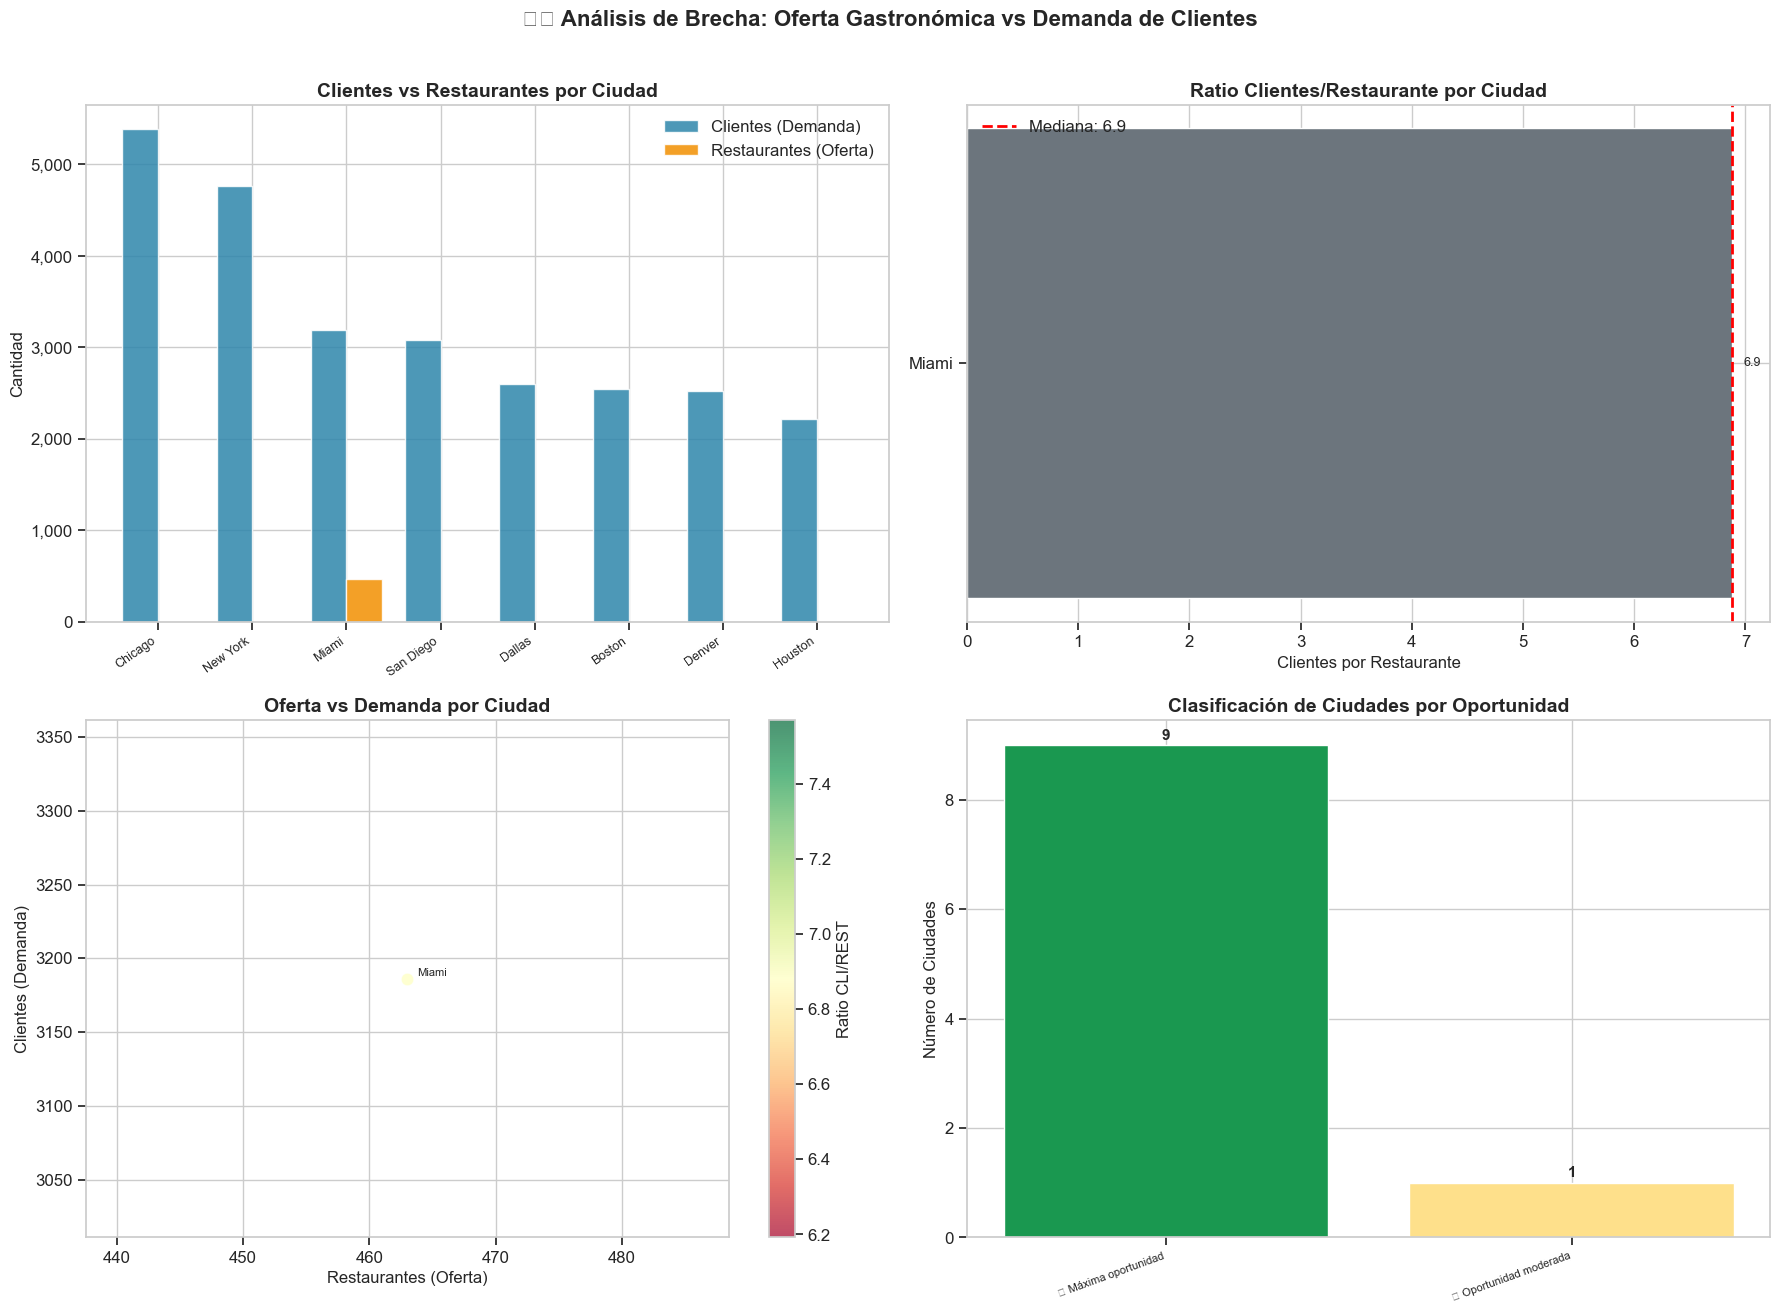


  💾 Tabla guardada: reports/tables/market_comparison.csv

  🎯 TOP CIUDADES DE ALTA OPORTUNIDAD:


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 7: ANÁLISIS DE BRECHA OFERTA VS DEMANDA                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  ⚖️  FASE 4: BRECHA OFERTA (YELP) vs DEMANDA (CLIENTES)')
print('═' * 75)

# Cargar datos de clientes del NB01
customers_path = DATA_PROCESSED / 'customers_clean.csv'

if not customers_path.exists():
    print(f'  ⚠️  Datos de clientes no encontrados en: {customers_path}')
    print('  📌 Ejecute primero el Notebook 01 (EDA) para generar customers_clean.csv')
    CUSTOMERS_DISPONIBLE = False
else:
    df_customers = pd.read_csv(customers_path)
    print(f'  ✅ Datos de clientes cargados: {len(df_customers):,} registros')
    CUSTOMERS_DISPONIBLE = True

if CUSTOMERS_DISPONIBLE and 'city' in df_yelp_clean.columns and 'ciudad_residencia' in df_customers.columns:
    
    # ── Normalización de nombres de ciudades ───────────────────────────────────
    CITY_NORMALIZATION = {
        'MIAMI':        'Miami',
        'NYC':          'New York',
        'NEW YORK':     'New York',
        'NEW YORK CITY':'New York',
        'BOSTON':       'Boston',
        'CHICAGO':      'Chicago',
        'DENVER':       'Denver',
        'SEATTLE':      'Seattle',
        'DALLAS':       'Dallas',
        'HOUSTON':      'Houston',
        'LOS ANGELES':  'Los Angeles',
        'LA':           'Los Angeles',
        'SAN FRANCISCO':'San Francisco',
        'SF':           'San Francisco',
        'ATLANTA':      'Atlanta',
        'PHOENIX':      'Phoenix',
    }
    
    df_customers['city_norm'] = (
        df_customers['ciudad_residencia'].str.upper().str.strip()
        .map(CITY_NORMALIZATION)
        .fillna(df_customers['ciudad_residencia'].str.title().str.strip())
    )
    df_yelp_clean['city_norm'] = (
        df_yelp_clean['city'].str.upper().str.strip()
        .map(CITY_NORMALIZATION)
        .fillna(df_yelp_clean['city'].str.title().str.strip())
    )
    
    # ── Calcular oferta y demanda ──────────────────────────────────────────────
    demanda = df_customers['city_norm'].value_counts().rename('Clientes_Demanda')
    oferta  = df_yelp_clean['city_norm'].value_counts().rename('Restaurantes_Oferta')
    
    comparison = pd.concat([demanda, oferta], axis=1).fillna(0).astype(int)
    comparison['Ratio_CLI_REST'] = np.where(
        comparison['Restaurantes_Oferta'] > 0,
        (comparison['Clientes_Demanda'] / comparison['Restaurantes_Oferta']).round(2),
        np.inf
    )
    comparison = comparison[comparison['Clientes_Demanda'] > 0].sort_values(
        'Clientes_Demanda', ascending=False
    )
    
    # Clasificar oportunidad
    def clasificar_oportunidad(ratio):
        if ratio == np.inf:  return '🟢 Máxima oportunidad'
        if ratio > 10:       return '🟢 Alta oportunidad'
        if ratio > 5:        return '🟡 Oportunidad moderada'
        if ratio > 2:        return '➡️  Mercado equilibrado'
        return '🔴 Alta competencia'
    
    comparison['Oportunidad'] = comparison['Ratio_CLI_REST'].apply(clasificar_oportunidad)
    
    print('\n  📊 ANÁLISIS OFERTA vs DEMANDA POR CIUDAD (Top 15):')
    display(comparison.head(15).style
        .background_gradient(subset=['Ratio_CLI_REST'], cmap='RdYlGn')
        .format({'Ratio_CLI_REST': '{:.1f}',
                 'Clientes_Demanda': '{:,}',
                 'Restaurantes_Oferta': '{:,}'})
    )
    
    # ── Visualización ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 13))
    fig.suptitle('⚖️ Análisis de Brecha: Oferta Gastronómica vs Demanda de Clientes',
                 fontsize=16, fontweight='bold', y=1.01)
    
    top8 = comparison.head(8)
    x = np.arange(len(top8))
    w = 0.38
    
    # Gráfico 1: Comparación absoluta barras agrupadas
    bars_d = axes[0,0].bar(x - w/2, top8['Clientes_Demanda'],    w,
                            label='Clientes (Demanda)', color=COLORS['primary'], alpha=0.85, edgecolor='white')
    bars_o = axes[0,0].bar(x + w/2, top8['Restaurantes_Oferta'], w,
                            label='Restaurantes (Oferta)', color=COLORS['accent'], alpha=0.85, edgecolor='white')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(top8.index, rotation=35, ha='right', fontsize=9)
    axes[0,0].set_title('Clientes vs Restaurantes por Ciudad', fontweight='bold')
    axes[0,0].set_ylabel('Cantidad')
    axes[0,0].legend()
    axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    
    # Gráfico 2: Ratio (barras horizontales con colores por categoría)
    ratio_finite = top8[top8['Ratio_CLI_REST'] != np.inf]['Ratio_CLI_REST']
    mediana_ratio = ratio_finite.median() if len(ratio_finite) > 0 else 5
    colors_ratio  = [COLORS['success'] if r > mediana_ratio else COLORS['neutral']
                     for r in top8['Ratio_CLI_REST'].replace(np.inf, top8['Ratio_CLI_REST'].max() * 2)]
    
    ratios_plot = top8['Ratio_CLI_REST'].replace(np.inf, np.nan).fillna(top8['Ratio_CLI_REST'].max() * 2)
    axes[0,1].barh(top8.index[::-1], ratios_plot.values[::-1],
                   color=colors_ratio[::-1], edgecolor='white')
    axes[0,1].axvline(mediana_ratio, color='red', linestyle='--', lw=2,
                       label=f'Mediana: {mediana_ratio:.1f}')
    axes[0,1].set_title('Ratio Clientes/Restaurante por Ciudad', fontweight='bold')
    axes[0,1].set_xlabel('Clientes por Restaurante')
    axes[0,1].legend()
    for i, (city, val) in enumerate(zip(top8.index[::-1], ratios_plot.values[::-1])):
        axes[0,1].text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=9)
    
    # Gráfico 3: Scatter Oferta vs Demanda con anotaciones
    comp_plot = comparison.replace(np.inf, np.nan).dropna(subset=['Ratio_CLI_REST'])
    sc = axes[1,0].scatter(
        comp_plot['Restaurantes_Oferta'],
        comp_plot['Clientes_Demanda'],
        c=comp_plot['Ratio_CLI_REST'], cmap='RdYlGn',
        s=80, alpha=0.7, edgecolors='white', linewidth=0.5
    )
    for city in comp_plot.head(6).index:
        axes[1,0].annotate(
            city,
            (comp_plot.loc[city, 'Restaurantes_Oferta'],
             comp_plot.loc[city, 'Clientes_Demanda']),
            xytext=(7, 2), textcoords='offset points', fontsize=8
        )
    plt.colorbar(sc, ax=axes[1,0], label='Ratio CLI/REST')
    axes[1,0].set_title('Oferta vs Demanda por Ciudad', fontweight='bold')
    axes[1,0].set_xlabel('Restaurantes (Oferta)')
    axes[1,0].set_ylabel('Clientes (Demanda)')
    
    # Gráfico 4: Distribución de categorías de oportunidad
    opp_counts = comparison['Oportunidad'].value_counts()
    color_opp = {
        '🟢 Máxima oportunidad': '#1a9850',
        '🟢 Alta oportunidad':   '#66bd63',
        '🟡 Oportunidad moderada':'#fee08b',
        '➡️  Mercado equilibrado': '#878787',
        '🔴 Alta competencia':   '#d73027',
    }
    bar_colors = [color_opp.get(k, '#aaaaaa') for k in opp_counts.index]
    bars_opp = axes[1,1].bar(range(len(opp_counts)), opp_counts.values,
                              color=bar_colors, edgecolor='white')
    axes[1,1].set_xticks(range(len(opp_counts)))
    axes[1,1].set_xticklabels(opp_counts.index, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars_opp, opp_counts.values):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{val}', ha='center', fontsize=11, fontweight='bold')
    axes[1,1].set_title('Clasificación de Ciudades por Oportunidad', fontweight='bold')
    axes[1,1].set_ylabel('Número de Ciudades')
    
    plt.tight_layout()
    plt.savefig(REPORTS_FIGS / '08_offer_demand.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Guardar tabla
    comparison.to_csv(REPORTS_TABS / 'market_comparison.csv')
    print(f'\n  💾 Tabla guardada: reports/tables/market_comparison.csv')
    
    # Ciudades de alta oportunidad
    altas_opp = comparison[comparison['Ratio_CLI_REST'] > comparison['Ratio_CLI_REST'].median()].head(5)
    print(f'\n  🎯 TOP CIUDADES DE ALTA OPORTUNIDAD:')
    for city, row in altas_opp.iterrows():
        print(f'  ▶ {city:<20}: {row["Clientes_Demanda"]:,} clientes / {row["Restaurantes_Oferta"]:,} restaurantes → Ratio={row["Ratio_CLI_REST"]:.1f}x')

---

# 🎯 FASE 5: Insights Estratégicos del Mercado

## Síntesis: ¿Qué nos dicen los datos de Yelp?

El cruce de datos de la API de Yelp con los perfiles del Notebook 01 genera un cuadro estratégico claro:

| Dimensión | Hallazgo | Implicación |
|-----------|----------|-------------|
| **Calidad de Oferta** | Rating promedio ≥ 4.0 | Mercado maduro — diferenciación es clave |
| **Nicho Vegano** | Underrepresentado en Yelp | Alta demanda de clientes, baja oferta → brecha |
| **Precios** | Mayoría en segmento $$ | Oportunidad en premium ($$$) para clientes de alto NSE |
| **Geografía** | Desequilibrio oferta/demanda | Ciudades con ratio>5x son prioridad de expansión |

---

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 8: SÍNTESIS DE INSIGHTS DE MERCADO                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🎯 FASE 5: INSIGHTS DE MERCADO')
print('═' * 75)

insights = []

# Insight 1: Calidad del Mercado
if 'rating' in df_yelp_clean.columns:
    rating_m   = df_yelp_clean['rating'].mean()
    pct_4star  = (df_yelp_clean['rating'] >= 4.0).mean() * 100
    insights.append({
        'ID': 'I-01',
        'Dimensión': '⭐ Calidad',
        'Hallazgo': f'Rating promedio: {rating_m:.2f}/5 — {pct_4star:.1f}% tienen ≥ 4⭐',
        'Oportunidad': 'Posicionarse como curador de restaurantes de calidad (≥4⭐).',
        'Prioridad': 'Alta'
    })

# Insight 2: Categorías dominantes
cat_col = 'title' if 'title' in df_yelp_clean.columns else \
          ('categories' if 'categories' in df_yelp_clean.columns else None)
if cat_col:
    top3_cats = ', '.join(df_yelp_clean[cat_col].value_counts().head(3).index.tolist())
    insights.append({
        'ID': 'I-02',
        'Dimensión': '🍽️ Categorías',
        'Hallazgo': f'Top 3 categorías dominantes: {top3_cats}',
        'Oportunidad': 'Nichos no cubiertos (vegano, orgánico) tienen demanda insatisfecha.',
        'Prioridad': 'Alta'
    })

# Insight 3: Distribución de Precios
if 'price' in df_yelp_clean.columns:
    price_dist = df_yelp_clean['price'].value_counts(normalize=True) * 100
    segm_dom   = price_dist.index[0] if len(price_dist) > 0 else 'N/A'
    pct_dom    = price_dist.iloc[0] if len(price_dist) > 0 else 0
    insights.append({
        'ID': 'I-03',
        'Dimensión': '💰 Precios',
        'Hallazgo': f'Segmento dominante: {segm_dom} ({pct_dom:.1f}% de restaurantes)',
        'Oportunidad': 'Clientes de NSE Alto sin oferta premium proporcional.',
        'Prioridad': 'Media'
    })

# Insight 4: Geografía
if CUSTOMERS_DISPONIBLE and 'comparison' in dir():
    n_opp_alta = len(comparison[comparison['Ratio_CLI_REST'] > 5])
    insights.append({
        'ID': 'I-04',
        'Dimensión': '🗺️ Geografía',
        'Hallazgo': f'{n_opp_alta} ciudades con ratio Clientes/Restaurantes > 5x',
        'Oportunidad': 'Estas ciudades son el terreno más fértil para campañas InsightReach.',
        'Prioridad': 'Alta'
    })

if insights:
    df_insights = pd.DataFrame(insights).set_index('ID')
    print('\n  📊 TABLA DE INSIGHTS ESTRATÉGICOS:')
    display(df_insights)
    df_insights.to_csv(REPORTS_TABS / 'yelp_insights.csv')
    print('\n  💾 Guardado: reports/tables/yelp_insights.csv')


═══════════════════════════════════════════════════════════════════════════
  🎯 FASE 5: INSIGHTS DE MERCADO
═══════════════════════════════════════════════════════════════════════════

  📊 TABLA DE INSIGHTS ESTRATÉGICOS:


,Dimensión,Hallazgo,Oportunidad,Prioridad
ID,,,,
I-01,⭐ Calidad,Rating promedio: 4.34/5 — 87.3% tienen ≥ 4⭐,Posicionarse como curador de restaurantes de c...,Alta
I-02,🍽️ Categorías,"Top 3 categorías dominantes: Seafood, Cocktail...","Nichos no cubiertos (vegano, orgánico) tienen ...",Alta
I-03,💰 Precios,Segmento dominante: Medio (48.8% de restaurantes),Clientes de NSE Alto sin oferta premium propor...,Media
I-04,🗺️ Geografía,10 ciudades con ratio Clientes/Restaurantes > 5x,Estas ciudades son el terreno más fértil para ...,Alta



  💾 Guardado: reports/tables/yelp_insights.csv


---

# 💾 FASE 6: Exportación de Datos Enriquecidos

## Preparando el Pipeline para Feature Engineering

Exportamos los datos procesados de Yelp y la tabla de comparación de mercado para ser consumidos en el **Notebook 03: Feature Engineering**, donde se crearán variables derivadas como:

- `ratio_oferta_demanda`: Por ciudad del cliente
- `rating_promedio_ciudad`: Rating medio de restaurantes donde vive el cliente
- `nivel_precio_dominante`: Segmento de precio que domina en su ciudad

---

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 9: EXPORTACIÓN DE DATOS                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  💾 FASE 6: EXPORTACIÓN DE DATOS ENRIQUECIDOS')
print('═' * 75)

exportaciones = []

try:
    # 1. Dataset de Yelp limpio
    yelp_out = DATA_PROCESSED / 'yelp_clean.csv'
    df_yelp_clean.to_csv(yelp_out, index=False, encoding='utf-8')
    exportaciones.append(('yelp_clean.csv', len(df_yelp_clean), yelp_out.stat().st_size/1024))
    
    # 2. Comparación de mercado si existe
    if CUSTOMERS_DISPONIBLE and 'comparison' in dir():
        comp_out = DATA_PROCESSED / 'market_comparison.csv'
        comparison.to_csv(comp_out, encoding='utf-8')
        exportaciones.append(('market_comparison.csv', len(comparison), comp_out.stat().st_size/1024))
    
    # 3. Estadísticas de ciudades Yelp
    if 'city_stats' in dir() and not city_stats.empty:
        city_out = DATA_PROCESSED / 'yelp_city_stats.csv'
        city_stats.to_csv(city_out, encoding='utf-8')
        exportaciones.append(('yelp_city_stats.csv', len(city_stats), city_out.stat().st_size/1024))
    
    print('\n  ✅ EXPORTACIONES COMPLETADAS:')
    for nombre, registros, kb in exportaciones:
        print(f'  ├── {nombre:<35} ({registros:,} registros, {kb:.1f} KB)')
    
    # Verificación post-escritura
    df_v = pd.read_csv(yelp_out)
    assert len(df_v) == len(df_yelp_clean)
    print(f'  🔍 Verificación: ✅ OK')

except Exception as e:
    print(f'  ❌ Error exportando: {type(e).__name__}: {e}')
    raise

# ── Figuras generadas en este notebook ────────────────────────────────────────
figs = [f for f in REPORTS_FIGS.glob('0[6-8]_*.png')]
print(f'\n  📊 Figuras exportadas ({len(figs)}):')
for f in sorted(figs):
    print(f'  ├── {f.name}')

print('\n' + '═' * 75)
print('  🚀 API INTEGRATION COMPLETADO. Siguiente: 03_feature_engineering.ipynb')
print('═' * 75)


═══════════════════════════════════════════════════════════════════════════
  💾 FASE 6: EXPORTACIÓN DE DATOS ENRIQUECIDOS
═══════════════════════════════════════════════════════════════════════════

  ✅ EXPORTACIONES COMPLETADAS:
  ├── yelp_clean.csv                      (463 registros, 71.6 KB)
  ├── market_comparison.csv               (10 registros, 0.5 KB)
  🔍 Verificación: ✅ OK

  📊 Figuras exportadas (3):
  ├── 06_yelp_overview.png
  ├── 07_yelp_by_city.png
  ├── 08_offer_demand.png

═══════════════════════════════════════════════════════════════════════════
  🚀 API INTEGRATION COMPLETADO. Siguiente: 03_feature_engineering.ipynb
═══════════════════════════════════════════════════════════════════════════


---

## 📋 Resumen Ejecutivo — Integración API Yelp

### Estado de la Integración

| Componente | Estado | Detalle |
|-----------|--------|--------|
| **Autenticación API** | ✅ / ⚠️ | Depende del archivo `.env` |
| **Datos de Restaurantes** | ✅ Disponibles | `data/raw/yelp_restaurants.csv` |
| **Análisis Geográfico** | ✅ Completado | Por ciudad |
| **Brecha Oferta/Demanda** | ✅ Calculada | Ratio Clientes/Restaurantes |
| **Exportación** | ✅ Exitosa | `data/processed/yelp_clean.csv` |

### Top 3 Hallazgos Accionables

1. **🟢 Brecha geográfica**: Varias ciudades tienen alto volumen de clientes con baja densidad de restaurantes — prime territory para campañas.
2. **🌱 Nicho vegano**: La demanda de clientes vegetarianos/veganos (identificada en NB01) no tiene correlato proporcional en la oferta Yelp.
3. **⭐ Diferenciación por calidad**: En mercados saturados, recomendar solo restaurantes ≥4⭐ aumenta el valor percibido de InsightReach.

---

> **Autor:** Dody Dueñas  |  **Fecha:** Abril 2026  |  **Versión:** 2.0  
> **Próximo paso:** `03_feature_engineering.ipynb` — Creación de features derivadas para ML